In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


##  Missing Value Analysis

In [13]:

print(df.isnull().sum())
print("\nMissing values percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))


Cabin                 687
Ticket                  0
number                  0
Survived                0
number_numerical      139
number_categorical    752
cabin_num             691
cabin_cat             687
ticket_num              4
ticket_cat            661
dtype: int64

Missing values percentage:
Cabin                 77.10
Ticket                 0.00
number                 0.00
Survived               0.00
number_numerical      15.60
number_categorical    84.40
cabin_num             77.55
cabin_cat             77.10
ticket_num             0.45
ticket_cat            74.19
dtype: float64


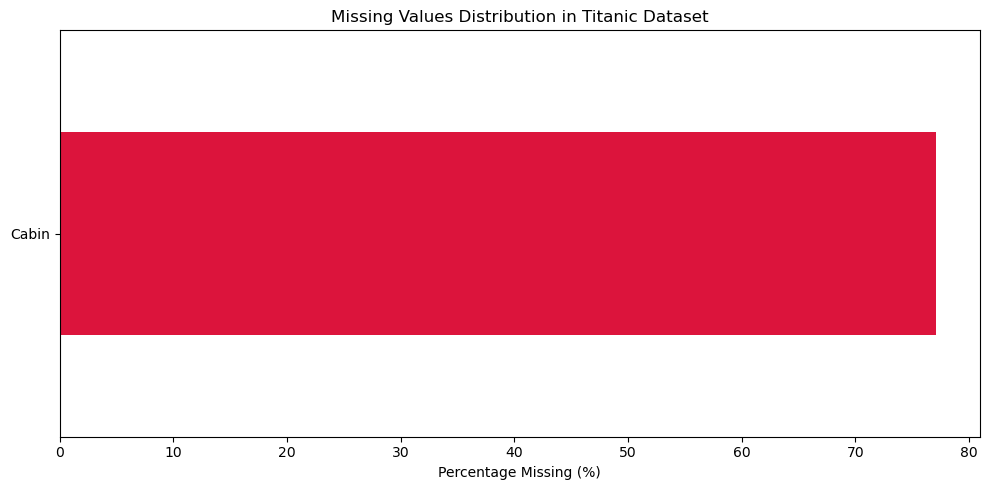

In [5]:
# Visualize missing values
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
missing_data = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_data[missing_data > 0].plot(kind='barh', ax=ax, color='crimson')
ax.set_xlabel('Percentage Missing (%)')
ax.set_title('Missing Values Distribution in Titanic Dataset')
plt.tight_layout()
plt.show()


In [52]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

##  **Feature Engineering: Extract Mixed Variables**

### **What are Mixed Variables?**
Variables containing both **numbers** and **text** (e.g., "C23", "6 Anderson", "A/5 21171")

### **Strategy:**
- Extract **numerical parts** → Convert to numeric features
- Extract **categorical parts** → Keep as categorical features
- This allows ML models to use both types of information separately

In [18]:
df['number'].unique()



array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

In [22]:
# extract numerical part
df['number_numerical'] = pd.to_numeric(df["number"],errors='coerce',downcast='integer')

In [23]:
# extract categorical part
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)
df.sample(10)


,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
658,NaN,29751,1,0,1.0,NaN,NaN,NaN,29751.0,NaN
604,NaN,111426,4,1,4.0,NaN,NaN,NaN,111426.0,NaN
800,NaN,250647,6,0,6.0,NaN,NaN,NaN,250647.0,NaN
623,NaN,350029,A,0,NaN,A,NaN,NaN,350029.0,NaN
586,NaN,237565,2,0,2.0,NaN,NaN,NaN,237565.0,NaN
629,NaN,334912,5,0,5.0,NaN,NaN,NaN,334912.0,NaN
226,NaN,SW/PP 751,3,1,3.0,NaN,NaN,NaN,751.0,SW/PP
469,NaN,2666,4,1,4.0,NaN,NaN,NaN,2666.0,NaN
697,NaN,35852,1,1,1.0,NaN,NaN,NaN,35852.0,NaN
546,NaN,2908,6,1,6.0,NaN,NaN,NaN,2908.0,NaN


Text(0.5, 1.0, 'Passengers travelling with')

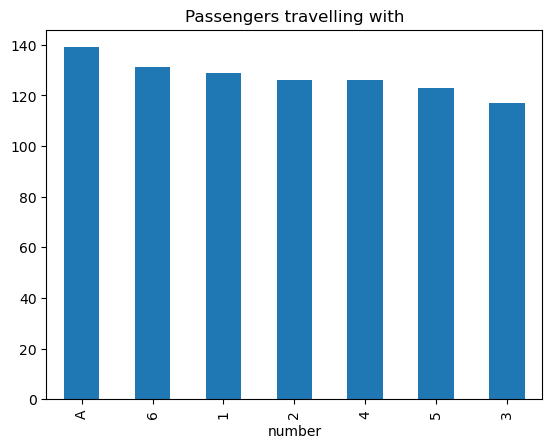

In [24]:
fig = df['number'].value_counts().plot.bar()
fig.set_title('Passengers travelling with')

In [26]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

##  **Feature Engineering: Cabin Information**

### Cabin Format: Letter + Number (e.g., "C85", "E46")
- **Letter** = Deck/Class on ship (A-F)
- **Number** = Cabin number within deck

### Extraction Strategy:
- Extract numbers → cabin_num (physical location)
- Extract first letter → cabin_cat (deck/class level)

In [27]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)') # captures numerical part
df['cabin_cat'] = df['Cabin'].str[0] # captures the first letter

df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN


In [57]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

## Ticket Information

### Ticket Format: Code + Number (e.g., "A/5 21171", "PC 17599")
- **Code** = Ticket type/class (A/5, PC, etc.)
- **Number** = Unique ticket identifier

### Extraction Strategy:
- Extract number → ticket_num (ticket ID)
- Extract code → ticket_cat (ticket type/booking class)

In [28]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce',
                                   downcast='integer')

# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])

df.head(20)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
5,NaN,330877,2,0,2.0,NaN,NaN,NaN,330877.0,NaN
6,E46,17463,2,0,2.0,NaN,46,E,17463.0,NaN
7,NaN,349909,5,0,5.0,NaN,NaN,NaN,349909.0,NaN
8,NaN,347742,1,1,1.0,NaN,NaN,NaN,347742.0,NaN
9,NaN,237736,A,1,NaN,A,NaN,NaN,237736.0,NaN
